# 🍵 Exploratory Data Analysis — Sri Lanka Tea Auction Price Prediction
**CS3121 Data Science Project — 2026**

---

This notebook performs a structured EDA on the preprocessed Sri Lanka tea auction dataset.

| Item | Detail |
|------|--------|
| **Dataset** | `tea_preprocessed.csv` — 1,154 rows, 182 features |
| **Target** | `price_mid_lkr` (midpoint auction price in LKR) |
| **Coverage** | Sales 1–10, January – March 2026 (Colombo Tea Auction) |

### EDA Structure
1. Setup & Data Loading  
2. Dataset Overview  
3. Figure 1 — Price Distribution Overview  
4. Figure 2 — Price Trends Across Auctions  
5. Figure 3 — Grade-Level Price Analysis  
6. Figure 4 — Feature Correlations with Price  
7. Figure 5 — Weather, Volume & Market Context  
8. Figure 6 — Price Range & Quality Tier Analysis  
9. Figure 7 — Weather Impact Analysis by Grade  
10. Key Findings Summary  

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Colour palettes
ELEV_COLORS = {'low_grown':'#2E7D32','high_grown':'#1565C0','medium_grown':'#6A1B9A'}
CAT_COLORS  = {'low_grown':'#2E7D32','high_grown':'#1565C0','dust':'#BF360C','off_grade':'#F57F17'}
group_colors = {'Weather (Current)':'#1565C0','Weather (Lagged)':'#6A1B9A',
                'Market & Sentiment':'#2E7D32','Production & FX':'#BF360C'}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
from pathlib import Path

root = Path.cwd().parent
data_path = root /'data' / 'Processed' / 'tea_preprocessed.csv'
data_path

WindowsPath('d:/Projects/data-analysis-for-tea-industry/data/Processed/tea_preprocessed.csv')

---
## 2. Data Loading & Overview

In [3]:
df = pd.read_csv(data_path)   
df_price = df.dropna(subset=['price_mid_lkr']).copy()

print(f'Total rows        : {len(df)}')
print(f'Rows with price   : {len(df_price)}')
print(f'Features          : {df.shape[1]}')
print(f'Sales             : {sorted(df["sale_number"].unique())}')
print(f'Months            : {list(df["sale_month"].unique())}')

Total rows        : 11523
Rows with price   : 11106
Features          : 185
Sales             : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]
Months            : ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', nan]


In [4]:
# Basic statistics of the target variable
print('=== Target Variable: price_mid_lkr ===')
print(df_price['price_mid_lkr'].describe().round(2))
print(f'\nSkewness : {df_price["price_mid_lkr"].skew():.3f}')
print(f'Kurtosis : {df_price["price_mid_lkr"].kurt():.3f}')

=== Target Variable: price_mid_lkr ===
count    11106.00
mean      1271.64
std        652.38
min        290.00
25%        910.00
50%       1115.00
75%       1425.00
max       6750.00
Name: price_mid_lkr, dtype: float64

Skewness : 3.207
Kurtosis : 15.632


In [5]:
# Category distribution
print('=== Elevation Distribution ===')
print(df['elevation'].value_counts())
print('\n=== Category Type Distribution ===')
print(df['category_type'].value_counts())
print('\n=== Missing values in key columns ===')
key_cols = ['price_mid_lkr','price_lo_lkr','price_hi_lkr','price_range_lkr','tier','grade']
print(df[key_cols].isnull().sum())

=== Elevation Distribution ===
elevation
low_grown       6557
high_grown      3481
medium_grown    1485
Name: count, dtype: int64

=== Category Type Distribution ===
category_type
low_grown     5072
off_grade     2376
dust          2079
high_grown    1996
Name: count, dtype: int64

=== Missing values in key columns ===
price_mid_lkr       417
price_lo_lkr        417
price_hi_lkr        633
price_range_lkr     633
tier               6451
grade              4455
dtype: int64


In [6]:
# Average price by main groupings
print('=== Avg Price by Elevation ===')
print(df_price.groupby('elevation')['price_mid_lkr'].agg(['mean','median','std','count']).round(1))
print('\n=== Avg Price by Category Type ===')
print(df_price.groupby('category_type')['price_mid_lkr'].agg(['mean','median','std','count']).round(1))
print('\n=== Avg Price by Sale Month ===')
print(df_price.groupby('sale_month')['price_mid_lkr'].agg(['mean','median','count']).round(1))

=== Avg Price by Elevation ===
                mean  median    std  count
elevation                                 
high_grown    1065.6  1070.0  267.4   3350
low_grown     1476.3  1300.0  776.0   6302
medium_grown   859.4   860.0  164.3   1454

=== Avg Price by Category Type ===
                 mean  median    std  count
category_type                              
dust            974.3   955.0  197.0   2043
high_grown     1153.4  1150.0  260.3   1996
low_grown      1616.7  1425.0  798.8   5072
off_grade       817.2   785.0  161.2   1995

=== Avg Price by Sale Month ===
              mean  median  count
sale_month                       
April       1290.2  1130.0    690
August      1272.4  1110.0    915
December    1274.9  1140.0    811
February    1288.4  1135.0    895
January     1289.7  1120.0   1006
July        1277.2  1090.0   1113
June        1258.0  1080.0    898
March       1246.6  1130.0    908
May         1299.5  1125.0    786
November    1248.3  1110.0    929
October     1

---
## 3. Figure 1 — Price Distribution Overview

Three panels showing: **(a)** the overall price histogram with mean/median lines, 
**(b)** price spread by elevation as boxplots, and **(c)** price spread by category type.

> **Expected finding:** Right-skewed distribution — a small number of premium lots pull the mean above the median. 
Low Grown teas consistently command higher prices.

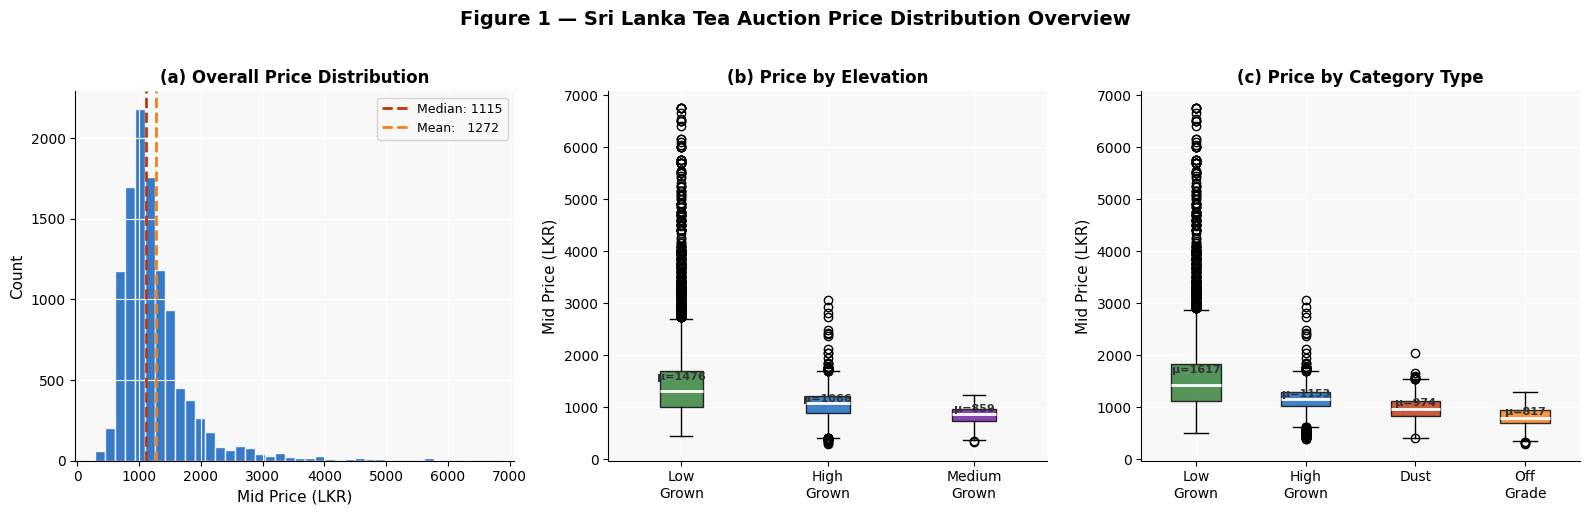

✓ Figure 1 saved


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1 — Sri Lanka Tea Auction Price Distribution Overview',
             fontsize=14, fontweight='bold', y=1.02)

# (a) Overall histogram
ax = axes[0]
ax.hist(df_price['price_mid_lkr'], bins=40, color='#1565C0', alpha=0.85, edgecolor='white')
ax.axvline(df_price['price_mid_lkr'].median(), color='#BF360C', lw=2, linestyle='--',
           label=f'Median: {df_price["price_mid_lkr"].median():.0f}')
ax.axvline(df_price['price_mid_lkr'].mean(), color='#F57F17', lw=2, linestyle='--',
           label=f'Mean:   {df_price["price_mid_lkr"].mean():.0f}')
ax.set_xlabel('Mid Price (LKR)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('(a) Overall Price Distribution', fontweight='bold')
ax.legend(fontsize=9)

# (b) Boxplot by elevation
ax = axes[1]
elev_order  = ['low_grown','high_grown','medium_grown']
elev_labels = ['Low\nGrown','High\nGrown','Medium\nGrown']
data_elev = [df_price[df_price['elevation']==e]['price_mid_lkr'].dropna() for e in elev_order]
bp = ax.boxplot(data_elev, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, col in zip(bp['boxes'], [ELEV_COLORS[e] for e in elev_order]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(elev_labels, fontsize=10)
ax.set_ylabel('Mid Price (LKR)', fontsize=11)
ax.set_title('(b) Price by Elevation', fontweight='bold')
for i, data in enumerate(data_elev, 1):
    ax.text(i, data.mean(), f'μ={data.mean():.0f}', ha='center', va='bottom',
            fontsize=8, color='#333', fontweight='bold')

# (c) Boxplot by category type
ax = axes[2]
cat_order  = ['low_grown','high_grown','dust','off_grade']
cat_labels = ['Low\nGrown','High\nGrown','Dust','Off\nGrade']
data_cat = [df_price[df_price['category_type']==c]['price_mid_lkr'].dropna() for c in cat_order]
bp2 = ax.boxplot(data_cat, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2))
for patch, col in zip(bp2['boxes'], [CAT_COLORS[c] for c in cat_order]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(cat_labels, fontsize=10)
ax.set_ylabel('Mid Price (LKR)', fontsize=11)
ax.set_title('(c) Price by Category Type', fontweight='bold')
for i, data in enumerate(data_cat, 1):
    ax.text(i, data.mean(), f'μ={data.mean():.0f}', ha='center', va='bottom',
            fontsize=8, color='#333', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 1 saved')

---
## 4. Figure 2 — Price Trends Across Auctions

Tracks how average price moves across **10 auction sales** (January–March 2026).

> **Expected finding:** Sale 1 (early January) starts highest. A mild downward drift is visible toward Sale 10, 
though prices remain broadly stable. Low Grown consistently outprices other elevations.

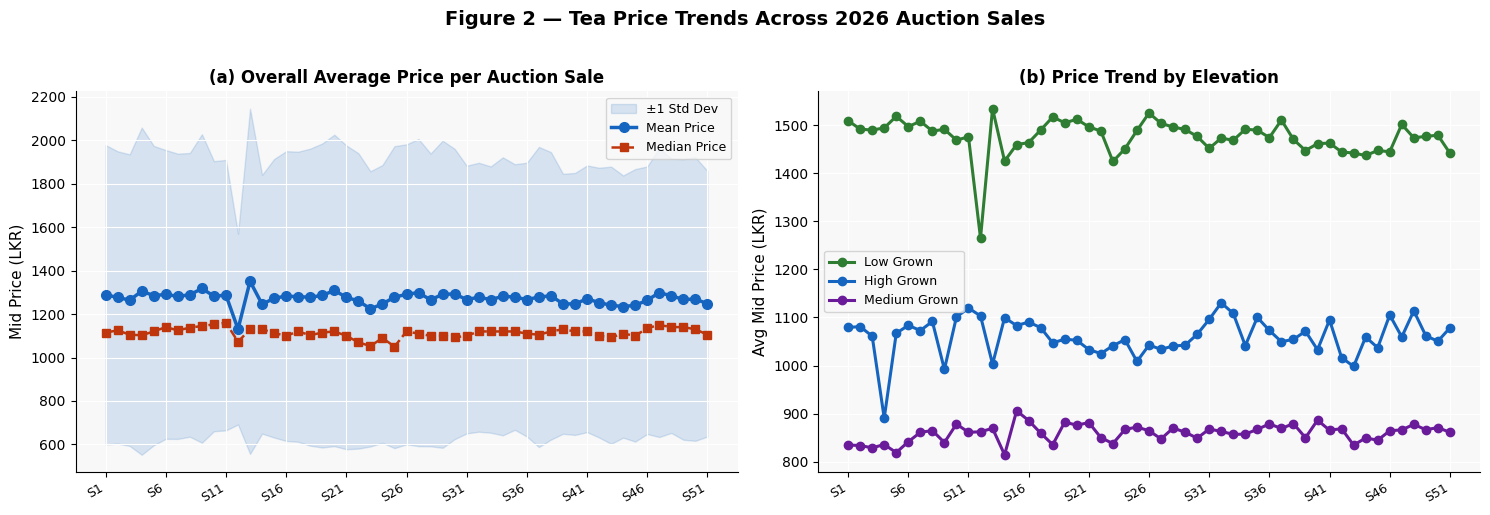

✓ Figure 2 saved


In [8]:
sale_nums = sorted(df_price['sale_number'].dropna().astype(int).unique())
sale_labels = {s: f'S{s}' for s in sale_nums}
max_xticks = 12
tick_step = max(1, int(np.ceil(len(sale_nums) / max_xticks)))
tick_sales = sale_nums[::tick_step]
if len(sale_nums) and tick_sales[-1] != sale_nums[-1]:
    tick_sales = tick_sales + [sale_nums[-1]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Figure 2 — Tea Price Trends Across 2026 Auction Sales',
             fontsize=14, fontweight='bold', y=1.02)

# (a) Overall mean & median per sale
ax = axes[0]
sale_stats = df_price.groupby('sale_number')['price_mid_lkr'].agg(['mean','median','std']).reset_index()
x = sale_stats['sale_number']
ax.fill_between(x, sale_stats['mean']-sale_stats['std'], sale_stats['mean']+sale_stats['std'],
                alpha=0.15, color='#1565C0', label='±1 Std Dev')
ax.plot(x, sale_stats['mean'],   'o-', color='#1565C0', lw=2.5, ms=7, label='Mean Price')
ax.plot(x, sale_stats['median'], 's--', color='#BF360C', lw=1.8, ms=6, label='Median Price')
ax.set_xticks(tick_sales)
ax.set_xticklabels([sale_labels.get(int(i), f'S{int(i)}') for i in tick_sales], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mid Price (LKR)', fontsize=11)
ax.set_title('(a) Overall Average Price per Auction Sale', fontweight='bold')
ax.legend(fontsize=9)

# (b) Per-elevation trend
ax = axes[1]
for elev, color in ELEV_COLORS.items():
    sub = df_price[df_price['elevation']==elev].groupby('sale_number')['price_mid_lkr'].mean()
    ax.plot(sub.index, sub.values, 'o-', color=color, lw=2.2, ms=6,
            label=elev.replace('_',' ').title())
ax.set_xticks(tick_sales)
ax.set_xticklabels([sale_labels[s] for s in tick_sales], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Avg Mid Price (LKR)', fontsize=11)
ax.set_title('(b) Price Trend by Elevation', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 2 saved')

---
## 5. Figure 3 — Grade-Level Price Analysis

**(a)** Top 12 grades by average price (horizontal bar chart).  
**(b)** Elevation × Category Type heatmap showing average prices for each combination.

> **Expected finding:** Fine tippy grades (FBOPF Tippy, OP1) command a significant premium. 
Off Grade teas are consistently the lowest regardless of elevation.

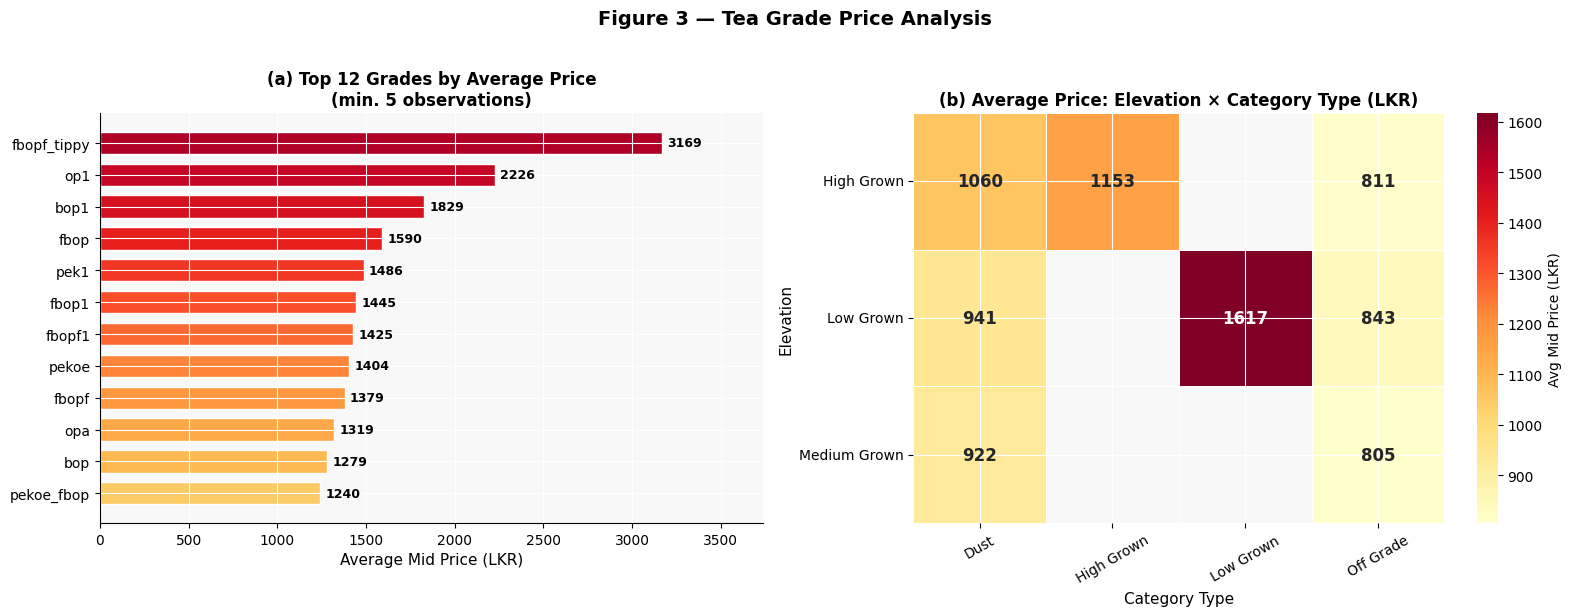

✓ Figure 3 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 3 — Tea Grade Price Analysis',
             fontsize=14, fontweight='bold', y=1.02)

# (a) Top 12 grades by avg price
ax = axes[0]
grade_prices = df_price.groupby('grade')['price_mid_lkr'].agg(['mean','count'])
grade_prices = grade_prices[grade_prices['count'] >= 5].sort_values('mean', ascending=True).tail(12)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(grade_prices)))
bars = ax.barh(grade_prices.index, grade_prices['mean'], color=colors, edgecolor='white', height=0.7)
for bar, (_, row) in zip(bars, grade_prices.iterrows()):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:.0f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Average Mid Price (LKR)', fontsize=11)
ax.set_title('(a) Top 12 Grades by Average Price\n(min. 5 observations)', fontweight='bold')
ax.set_xlim(0, grade_prices['mean'].max() * 1.18)

# (b) Elevation x Category heatmap
ax = axes[1]
pivot = df_price.groupby(['elevation','category_type'])['price_mid_lkr'].mean().unstack()
pivot.index   = [i.replace('_',' ').title() for i in pivot.index]
pivot.columns = [c.replace('_',' ').title() for c in pivot.columns]
sns.heatmap(pivot, ax=ax, annot=True, fmt='.0f', cmap='YlOrRd',
            mask=pivot.isnull(), linewidths=0.5, linecolor='white',
            annot_kws={'size':12,'weight':'bold'},
            cbar_kws={'label':'Avg Mid Price (LKR)'})
ax.set_title('(b) Average Price: Elevation × Category Type (LKR)', fontweight='bold')
ax.set_xlabel('Category Type', fontsize=11)
ax.set_ylabel('Elevation', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig3_grade_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 3 saved')

---
## 6. Figure 4 — Feature Correlations with Price

Pearson correlations between `price_mid_lkr` and four groups of features:
- 🔵 **Weather (Current)** — precipitation, sunshine, temperature at auction time
- 🟣 **Weather (Lagged)** — weather from 1–3 auctions prior
- 🟢 **Market & Sentiment** — demand scores, sentiment scores, volume YoY change
- 🔴 **Production & FX** — Sri Lanka production, FX rates, volumes sold

> **Expected finding:** All macro/weather features show weak direct correlation (< 0.05). 
This is an important result — it suggests **grade and category are the primary price drivers**, 
and macro signals may interact with them rather than acting independently.

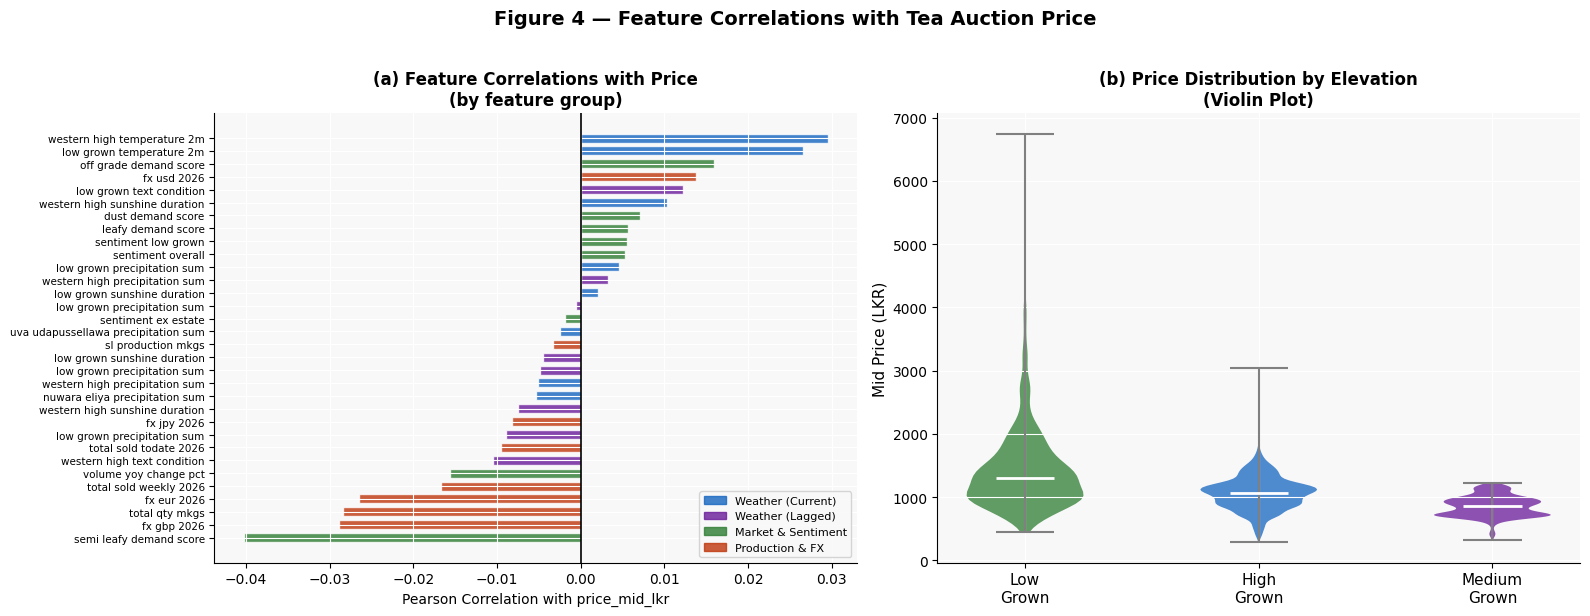

✓ Figure 4 saved


In [10]:
feature_groups = {
    'Weather (Current)': [
        'low_grown__precipitation_sum_total','western_high__precipitation_sum_total',
        'nuwara_eliya__precipitation_sum_total','uva_udapussellawa__precipitation_sum_total',
        'low_grown__sunshine_duration_total','western_high__sunshine_duration_total',
        'low_grown__temperature_2m_mean_mean','western_high__temperature_2m_mean_mean',
    ],
    'Weather (Lagged)': [
        'low_grown__precipitation_sum_total_lag1','low_grown__precipitation_sum_total_lag2',
        'low_grown__precipitation_sum_total_lag3','western_high__precipitation_sum_total_lag1',
        'low_grown__sunshine_duration_total_lag1','western_high__sunshine_duration_total_lag1',
        'low_grown__text_condition_score_lag1','western_high__text_condition_score_lag1',
    ],
    'Market & Sentiment': [
        'sentiment_overall','sentiment_ex_estate','sentiment_low_grown',
        'volume_yoy_change_pct','dust__demand_score','leafy__demand_score',
        'off_grade__demand_score','semi_leafy__demand_score',
    ],
    'Production & FX': [
        'sl_production_mkgs','fx_usd_2026','fx_gbp_2026','fx_eur_2026','fx_jpy_2026',
        'total_sold_weekly_2026','total_sold_todate_2026','total__qty_mkgs',
    ],
}

all_features, all_corrs, all_groups = [], [], []
for grp, features in feature_groups.items():
    valid = [f for f in features if f in df_price.columns]
    corrs = df_price[valid + ['price_mid_lkr']].corr()['price_mid_lkr'].drop('price_mid_lkr')
    for feat, corr in corrs.items():
        label = feat.replace('__',' ').replace('_',' ')
        label = ' '.join(label.split()[:4])
        all_features.append(label)
        all_corrs.append(corr)
        all_groups.append(grp)

corr_df = pd.DataFrame({'feature':all_features,'corr':all_corrs,'group':all_groups})
corr_df = corr_df.sort_values('corr')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 4 — Feature Correlations with Tea Auction Price',
             fontsize=14, fontweight='bold', y=1.02)

# (a) Correlation bar chart
ax = axes[0]
bar_colors = [group_colors[g] for g in corr_df['group']]
ax.barh(range(len(corr_df)), corr_df['corr'], color=bar_colors, alpha=0.8, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=1.2)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['feature'], fontsize=7.5)
ax.set_xlabel('Pearson Correlation with price_mid_lkr', fontsize=10)
ax.set_title('(a) Feature Correlations with Price\n(by feature group)', fontweight='bold')
patches = [mpatches.Patch(color=c, label=g, alpha=0.8) for g, c in group_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')

# (b) Violin plot: price by elevation
ax = axes[1]
elev_order  = ['low_grown','high_grown','medium_grown']
elev_labels = ['Low\nGrown','High\nGrown','Medium\nGrown']
groups_vio  = [df_price[df_price['elevation']==e]['price_mid_lkr'].dropna() for e in elev_order]
colors_vio  = [ELEV_COLORS[e] for e in elev_order]
parts = ax.violinplot(groups_vio, positions=range(len(groups_vio)), showmedians=True)
for pc, col in zip(parts['bodies'], colors_vio):
    pc.set_facecolor(col); pc.set_alpha(0.75)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
for key in ['cbars','cmins','cmaxes']:
    parts[key].set_color('gray')
ax.set_xticks(range(len(groups_vio)))
ax.set_xticklabels(elev_labels, fontsize=11)
ax.set_ylabel('Mid Price (LKR)', fontsize=11)
ax.set_title('(b) Price Distribution by Elevation\n(Violin Plot)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 4 saved')

---
## 7. Figure 5 — Weather, Volume & Market Context

Four panels examining the **external drivers** of auction prices:
- **(a)** Precipitation across 4 tea-growing regions per sale
- **(b)** Auction volume YoY change per sale
- **(c)** Scatter: avg precipitation vs avg price per sale
- **(d)** Weekly auction volumes: 2026 vs 2025

> **Expected finding:** 2026 volumes are running ~4.9% below 2025 on average — a supply contraction. 
Precipitation varies meaningfully across regions, but does not map directly to price in this short window.

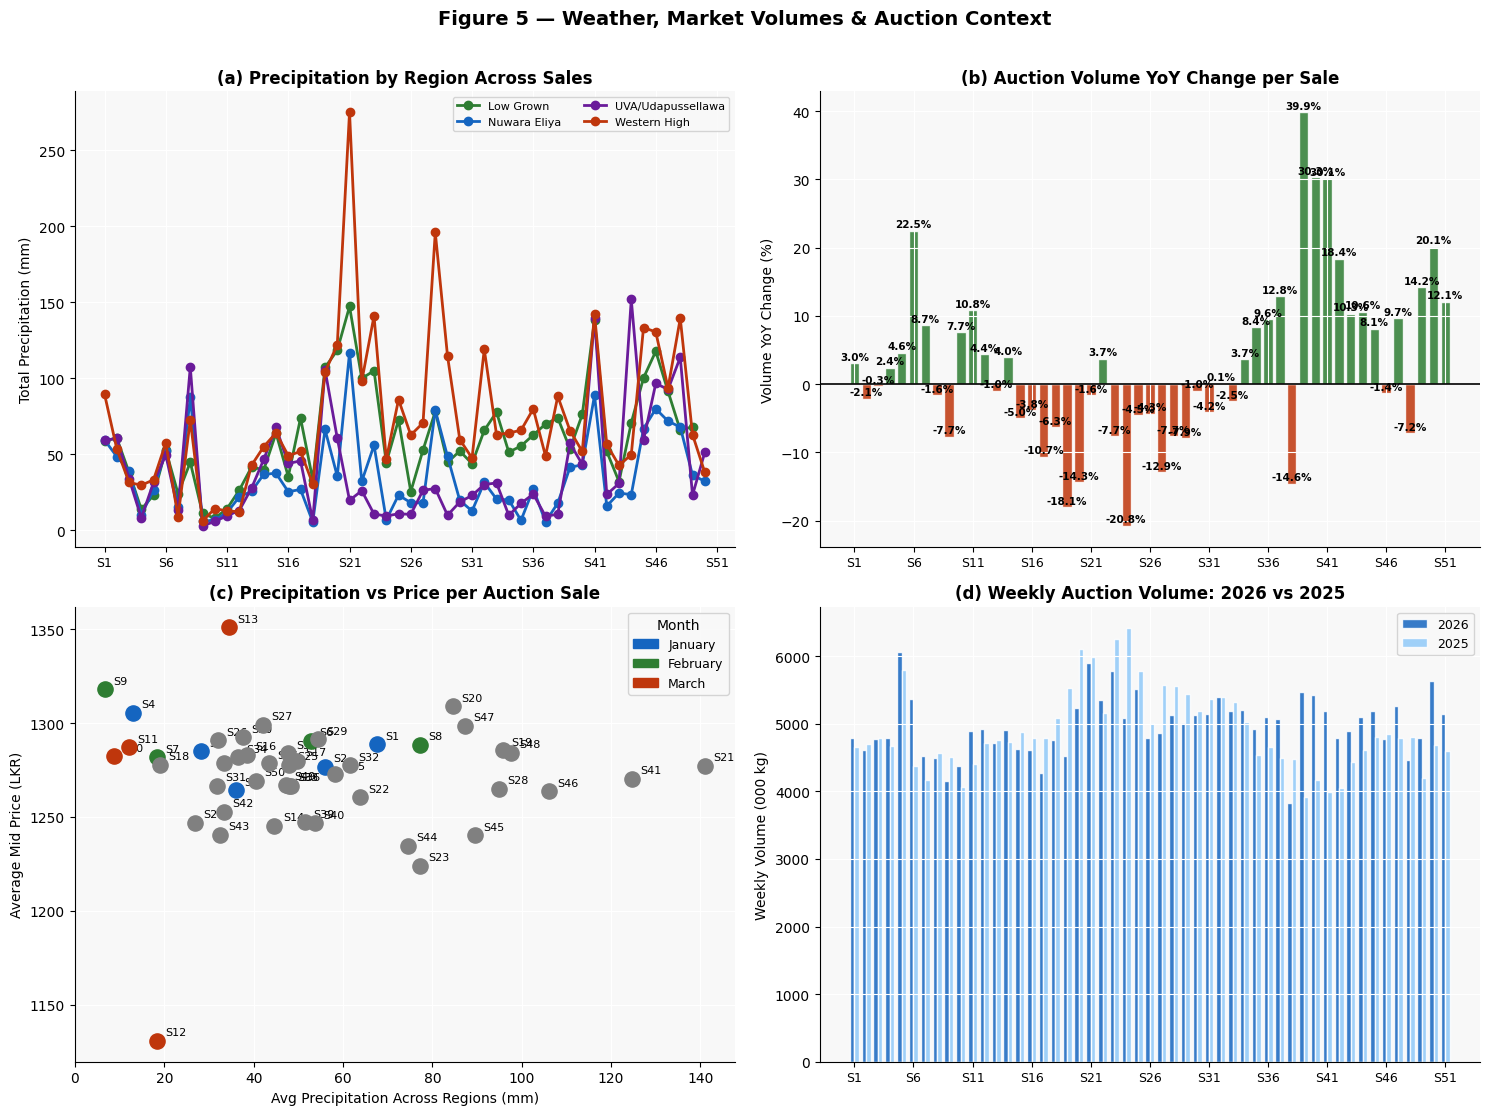

✓ Figure 5 saved


In [11]:
sale_nums = sorted(df['sale_number'].dropna().astype(int).unique())
sale_labels_short = {s: f'S{s}' for s in sale_nums}
max_xticks = 12
tick_step = max(1, int(np.ceil(len(sale_nums) / max_xticks)))
tick_sales = sale_nums[::tick_step]
if len(sale_nums) and tick_sales[-1] != sale_nums[-1]:
    tick_sales = tick_sales + [sale_nums[-1]]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Figure 5 — Weather, Market Volumes & Auction Context',
             fontsize=14, fontweight='bold', y=1.01)

# (a) Precipitation by region
ax = axes[0, 0]
precip_cols = {
    'Low Grown':        'low_grown__precipitation_sum_total',
    'Nuwara Eliya':     'nuwara_eliya__precipitation_sum_total',
    'UVA/Udapussellawa':'uva_udapussellawa__precipitation_sum_total',
    'Western High':     'western_high__precipitation_sum_total',
}
region_colors = ['#2E7D32','#1565C0','#6A1B9A','#BF360C']
for (region, col), color in zip(precip_cols.items(), region_colors):
    if col in df.columns:
        vals = df.groupby('sale_number')[col].mean()
        ax.plot(vals.index, vals.values, 'o-', label=region, color=color, lw=2, ms=6)
ax.set_xticks(tick_sales)
ax.set_xticklabels([sale_labels_short[s] for s in tick_sales], fontsize=9)
ax.set_ylabel('Total Precipitation (mm)', fontsize=10)
ax.set_title('(a) Precipitation by Region Across Sales', fontweight='bold')
ax.legend(fontsize=8, ncol=2)

# (b) Volume YoY change
ax = axes[0, 1]
vol_per_sale = df.groupby('sale_number')['volume_yoy_change_pct'].first()
bar_cols = ['#2E7D32' if v >= 0 else '#BF360C' for v in vol_per_sale.values]
bars = ax.bar(vol_per_sale.index, vol_per_sale.values, color=bar_cols, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=1.2)
ax.set_xticks(tick_sales)
ax.set_xticklabels([sale_labels_short[s] for s in tick_sales], fontsize=9)
ax.set_ylabel('Volume YoY Change (%)', fontsize=10)
ax.set_title('(b) Auction Volume YoY Change per Sale', fontweight='bold')
for bar, val in zip(bars, vol_per_sale.values):
    if np.isfinite(val):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}%', ha='center', fontsize=7.5, fontweight='bold')

# (c) Precipitation vs price scatter
ax = axes[1, 0]
scatter_df = df_price.groupby('sale_number').agg(
    avg_price=('price_mid_lkr','mean'),
    avg_precip=('all_regions__avg_precipitation','mean'),
    sale_month=('sale_month','first')
).reset_index()
month_colors = {'January':'#1565C0','February':'#2E7D32','March':'#BF360C'}
for _, row in scatter_df.iterrows():
    color = month_colors.get(row['sale_month'], 'gray')
    ax.scatter(row['avg_precip'], row['avg_price'], color=color, s=120, zorder=5)
    ax.annotate(f"S{int(row['sale_number'])}", (row['avg_precip'], row['avg_price']),
                textcoords='offset points', xytext=(6,4), fontsize=8)
patches2 = [mpatches.Patch(color=c, label=m) for m, c in month_colors.items()]
ax.legend(handles=patches2, fontsize=9, title='Month')
ax.set_xlabel('Avg Precipitation Across Regions (mm)', fontsize=10)
ax.set_ylabel('Average Mid Price (LKR)', fontsize=10)
ax.set_title('(c) Precipitation vs Price per Auction Sale', fontweight='bold')

# (d) Weekly volumes 2026 vs 2025
ax = axes[1, 1]
vol_df = df.groupby('sale_number').agg(
    w26=('total_sold_weekly_2026','first'),
    w25=('total_sold_weekly_2025','first')
).reset_index()
x = np.array(vol_df['sale_number'])
width = 0.38
ax.bar(x-width/2, vol_df['w26']/1000, width, label='2026', color='#1565C0', alpha=0.85, edgecolor='white')
ax.bar(x+width/2, vol_df['w25']/1000, width, label='2025', color='#90CAF9', alpha=0.85, edgecolor='white')
ax.set_xticks(tick_sales)
ax.set_xticklabels([sale_labels_short[int(s)] for s in tick_sales], fontsize=9)
ax.set_ylabel('Weekly Volume (000 kg)', fontsize=10)
ax.set_title('(d) Weekly Auction Volume: 2026 vs 2025', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig5_context.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 5 saved')

---
## 8. Figure 6 — Price Range & Quality Tier Analysis

**(a)** Distribution of within-category price range (high − low), indicating quality heterogeneity.  
**(b)** Price by quality tier (Best / Select Best / Below Best / Others) for Low-Grown teas.

> **Expected finding:** The **Best** tier commands a clear premium. A wide price range within a category 
suggests that even within the same grade label, quality varies — supporting the need for ML-based pricing.

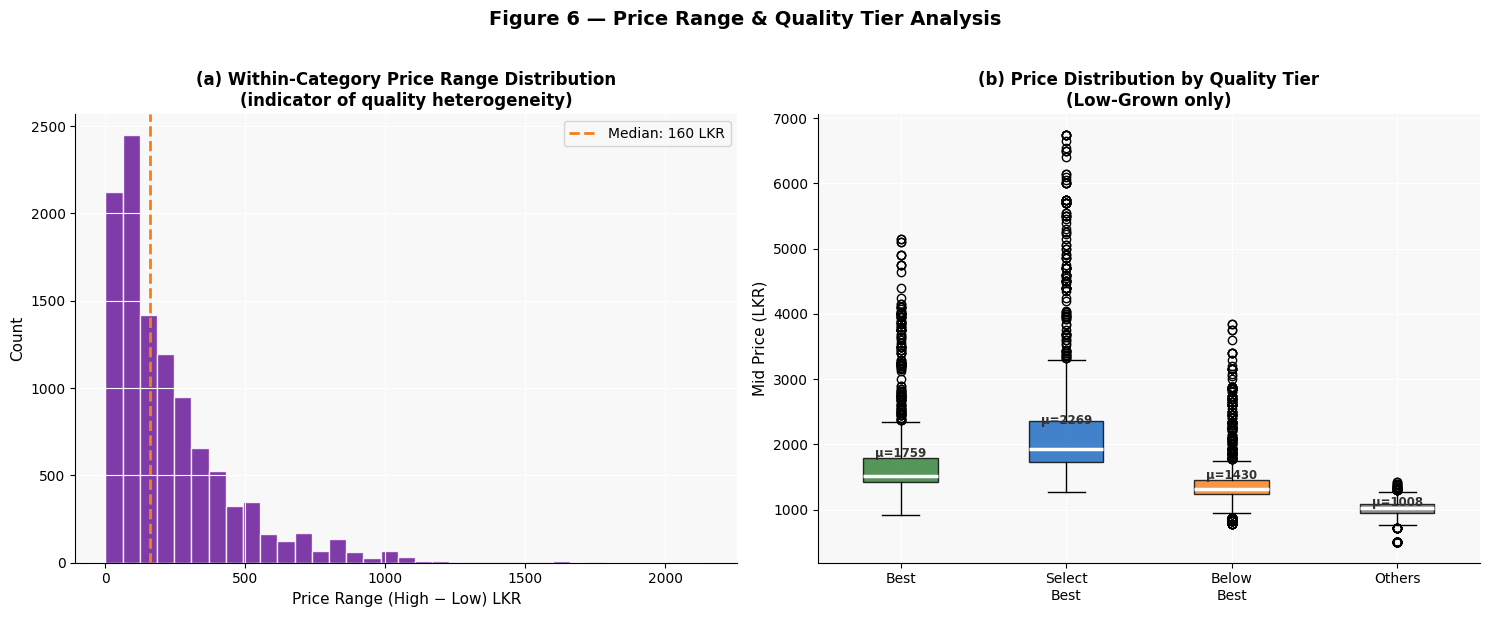

✓ Figure 6 saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 6 — Price Range & Quality Tier Analysis',
             fontsize=14, fontweight='bold', y=1.02)

# (a) Price range histogram
ax = axes[0]
pr = df_price.dropna(subset=['price_range_lkr'])
ax.hist(pr['price_range_lkr'], bins=35, color='#6A1B9A', alpha=0.85, edgecolor='white')
ax.axvline(pr['price_range_lkr'].median(), color='#F57F17', lw=2, linestyle='--',
           label=f'Median: {pr["price_range_lkr"].median():.0f} LKR')
ax.set_xlabel('Price Range (High − Low) LKR', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('(a) Within-Category Price Range Distribution\n(indicator of quality heterogeneity)', fontweight='bold')
ax.legend(fontsize=10)

# (b) Boxplot by tier
ax = axes[1]
tier_data   = df_price.dropna(subset=['tier'])
tier_order  = ['best','select_best','below_best','others']
tier_labels = ['Best','Select\nBest','Below\nBest','Others']
tier_colors = ['#2E7D32','#1565C0','#F57F17','#757575']
data_tier   = [tier_data[tier_data['tier']==t]['price_mid_lkr'].dropna() for t in tier_order]
bp3 = ax.boxplot(data_tier, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2.5))
for patch, col in zip(bp3['boxes'], tier_colors):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(tier_labels, fontsize=10)
ax.set_ylabel('Mid Price (LKR)', fontsize=11)
ax.set_title('(b) Price Distribution by Quality Tier\n(Low-Grown only)', fontweight='bold')
for i, data in enumerate(data_tier, 1):
    if len(data):
        ax.text(i, data.mean(), f'μ={data.mean():.0f}', ha='center', va='bottom',
                fontsize=8.5, color='#333', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_tier_range.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 6 saved')

---
## 9. Figure 7 — Weather Impact Analysis by Grade

Four panels measuring how weather affects the price of each individual tea grade:

- **(a) Correlation Heatmap** — Pearson correlation between each weather feature and price, broken down by grade. Red = negative correlation (rain hurts price), Blue = positive.
- **(b) Sensitivity Ranking** — Grades ranked by *mean absolute correlation* across all weather features — the higher the score, the more weather-reactive the grade.
- **(c) Price vs Precipitation Scatter** — The 5 most weather-sensitive grades plotted against avg regional precipitation, with trend lines.
- **(d) Price by Weather Severity** — Boxplots for the single most affected grade, split into Low / Moderate / High weather severity buckets.

> **Key question answered:** Which tea grade is most exposed to weather variation?

Eligible grades (≥10 obs): 14
Rows in analysis          : 7068

Grade weather sensitivity (mean |corr|):
  PEKOE FBOP                    0.067 ← MOST AFFECTED
  OP1                           0.056
  FBOPF1                        0.034
  BOP                           0.032
  OP                            0.030
  OPA                           0.029
  BOPF                          0.025
  PEKOE                         0.022
  FBOPF TIPPY                   0.021
  FBOP1                         0.020
  FBOP                          0.018
  FBOPF                         0.014
  PEK1                          0.013
  BOP1                          0.012


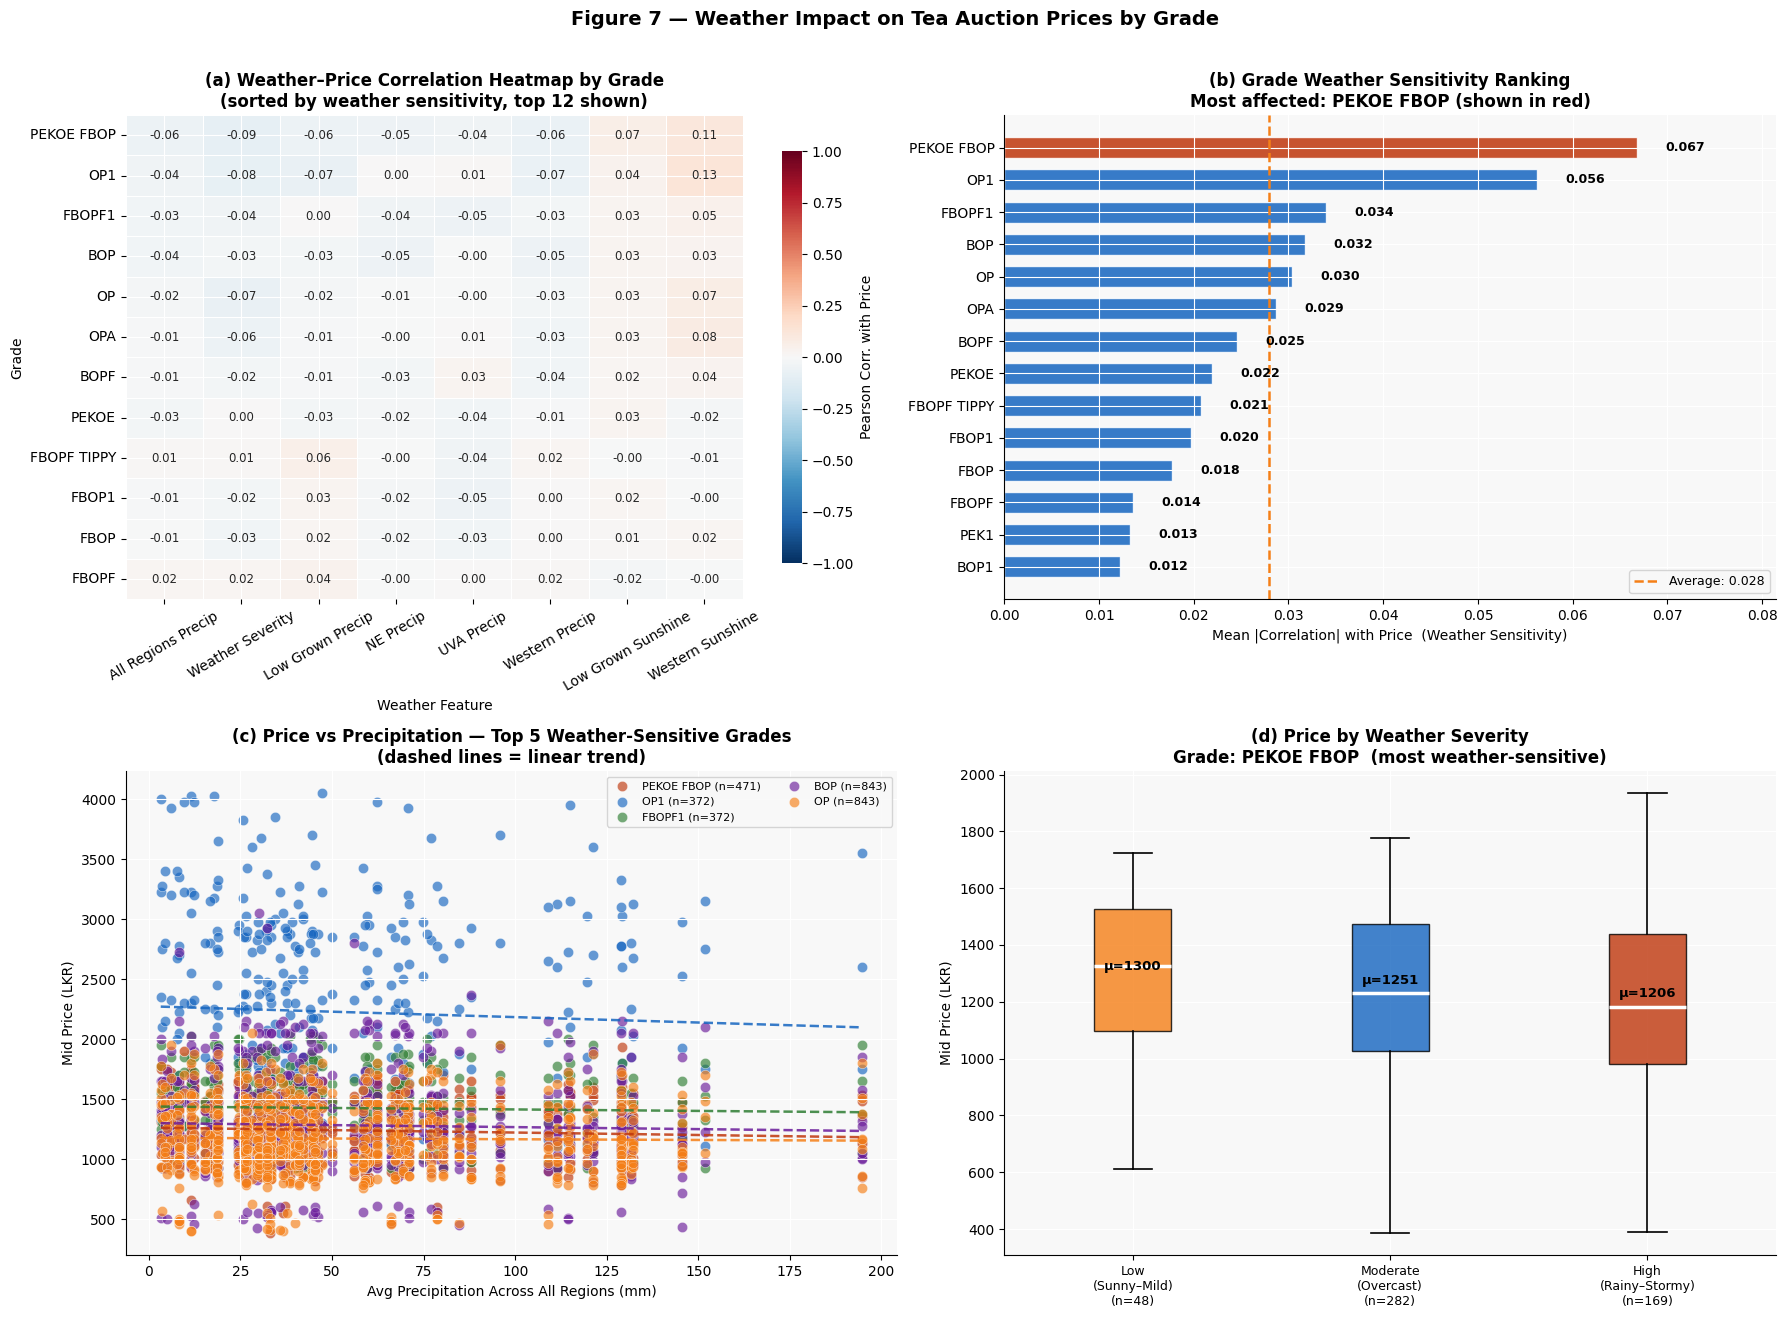

✓ Figure 7 saved

>>> Most weather-affected grade: PEKOE FBOP  (sensitivity score: 0.067)


In [13]:
# ── Figure 7: Weather Impact on Tea Prices by Grade ────────────────────────────

# 1. Weather features to test
weather_feature_map = {
    'All Regions\nPrecip':  'all_regions__avg_precipitation',
    'Weather\nSeverity':    'avg_weather_severity',
    'Low Grown\nPrecip':    'low_grown__precipitation_sum_total',
    'NE\nPrecip':           'nuwara_eliya__precipitation_sum_total',
    'UVA\nPrecip':          'uva_udapussellawa__precipitation_sum_total',
    'Western\nPrecip':      'western_high__precipitation_sum_total',
    'Low Grown\nSunshine':  'low_grown__sunshine_duration_total',
    'Western\nSunshine':    'western_high__sunshine_duration_total',
}
weather_feature_map = {k: v for k, v in weather_feature_map.items() if v in df_price.columns}

# 2. Filter: rows with a grade AND price, grade must have ≥ 10 observations
df_g = df_price.dropna(subset=['grade']).copy()
grade_counts  = df_g['grade'].value_counts()
eligible      = grade_counts[grade_counts >= 10].index.tolist()
df_g          = df_g[df_g['grade'].isin(eligible)].copy()

print(f'Eligible grades (≥10 obs): {len(eligible)}')
print(f'Rows in analysis          : {len(df_g)}')

# 3. Compute per-grade Pearson correlation with price for each weather feature
corr_records = {}
for grade in eligible:
    sub = df_g[df_g['grade'] == grade]
    row = {}
    for label, col in weather_feature_map.items():
        vals = sub[[col, 'price_mid_lkr']].dropna()
        row[label] = vals.corr().iloc[0, 1] if (len(vals) >= 5 and vals[col].nunique() > 1) else np.nan
    corr_records[grade] = row

corr_df_grade = pd.DataFrame(corr_records).T          # shape: grades × weather features

# 4. Sensitivity = mean |correlation| across weather features
sensitivity   = corr_df_grade.abs().mean(axis=1).sort_values(ascending=False)
top5_grades   = sensitivity.head(5).index.tolist()
most_affected = sensitivity.index[0]

fmt_grade = lambda g: g.replace('_', ' ').upper()

print('\nGrade weather sensitivity (mean |corr|):')
for g in sensitivity.index:
    marker = ' ← MOST AFFECTED' if g == most_affected else ''
    print(f'  {fmt_grade(g):28s}  {sensitivity[g]:.3f}{marker}')

# ── Build Figure 7 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Figure 7 — Weather Impact on Tea Auction Prices by Grade',
             fontsize=14, fontweight='bold', y=1.01)

# ── (a) Heatmap: grades × weather features ─────────────────────────────────────
ax = axes[0, 0]
# Sort grades by sensitivity (most sensitive at top); limit to 12 for readability
top_hmap = sensitivity.head(12).index.tolist()
hmap_data = corr_df_grade.loc[top_hmap].copy()
hmap_data.index   = [fmt_grade(g) for g in hmap_data.index]
hmap_data.columns = [c.replace('\n', ' ') for c in hmap_data.columns]

sns.heatmap(
    hmap_data, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8.5},
    mask=hmap_data.isnull(),
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Pearson Corr. with Price', 'shrink': 0.85}
)
ax.set_title('(a) Weather–Price Correlation Heatmap by Grade\n'
             '(sorted by weather sensitivity, top 12 shown)',
             fontweight='bold')
ax.set_xlabel('Weather Feature', fontsize=10)
ax.set_ylabel('Grade', fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

# ── (b) Sensitivity ranking bar chart ──────────────────────────────────────────
ax = axes[0, 1]
sens_plot = sensitivity.copy()
sens_plot.index = [fmt_grade(g) for g in sens_plot.index]
n = len(sens_plot)
bar_colors = ['#BF360C'] + ['#1565C0'] * (n - 1)   # highlight top grade in red

bars = ax.barh(sens_plot.index[::-1], sens_plot.values[::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='white', height=0.65)
ax.axvline(sensitivity.mean(), color='#F57F17', lw=1.8, linestyle='--',
           label=f'Average: {sensitivity.mean():.3f}')
for bar, val in zip(bars, sens_plot.values[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Mean |Correlation| with Price  (Weather Sensitivity)', fontsize=10)
ax.set_title('(b) Grade Weather Sensitivity Ranking\n'
             f'Most affected: {fmt_grade(most_affected)} (shown in red)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, sens_plot.max() * 1.22)

# ── (c) Scatter: price vs avg precipitation for top 5 sensitive grades ──────────
ax = axes[1, 0]
precip_col    = 'all_regions__avg_precipitation'
scatter_colors = ['#BF360C', '#1565C0', '#2E7D32', '#6A1B9A', '#F57F17']

if precip_col in df_g.columns:
    for grade, color in zip(top5_grades, scatter_colors):
        sub = df_g[df_g['grade'] == grade][[precip_col, 'price_mid_lkr']].dropna()
        ax.scatter(sub[precip_col], sub['price_mid_lkr'],
                   color=color, alpha=0.65, s=55,
                   label=f'{fmt_grade(grade)} (n={len(sub)})',
                   edgecolors='white', linewidth=0.4)
        if len(sub) >= 4:
            z  = np.polyfit(sub[precip_col], sub['price_mid_lkr'], 1)
            xs = np.linspace(sub[precip_col].min(), sub[precip_col].max(), 50)
            ax.plot(xs, np.poly1d(z)(xs), color=color, lw=1.8, linestyle='--', alpha=0.85)

ax.set_xlabel('Avg Precipitation Across All Regions (mm)', fontsize=10)
ax.set_ylabel('Mid Price (LKR)', fontsize=10)
ax.set_title('(c) Price vs Precipitation — Top 5 Weather-Sensitive Grades\n'
             '(dashed lines = linear trend)', fontweight='bold')
ax.legend(fontsize=8, ncol=2)

# ── (d) Price by weather severity — most affected grade ─────────────────────────
ax = axes[1, 1]
sev_col = 'avg_weather_severity'

if sev_col in df_g.columns:
    df_most = df_g[df_g['grade'] == most_affected][['price_mid_lkr', sev_col]].dropna().copy()
    sev_bins   = [0, 2, 3, 5]
    sev_labels = ['Low\n(Sunny–Mild)', 'Moderate\n(Overcast)', 'High\n(Rainy–Stormy)']
    df_most['sev_bin'] = pd.cut(df_most[sev_col], bins=sev_bins, labels=sev_labels)

    groups_sev = [df_most[df_most['sev_bin'] == l]['price_mid_lkr'].dropna() for l in sev_labels]
    sev_colors = ['#F57F17', '#1565C0', '#BF360C']

    bp4 = ax.boxplot(groups_sev, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2.5),
                     whiskerprops=dict(linewidth=1.2),
                     capprops=dict(linewidth=1.2))
    for patch, col in zip(bp4['boxes'], sev_colors):
        patch.set_facecolor(col); patch.set_alpha(0.8)

    tick_labels = [f'{l}\n(n={len(g)})' for l, g in zip(sev_labels, groups_sev)]
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylabel('Mid Price (LKR)', fontsize=10)
    ax.set_title(f'(d) Price by Weather Severity\nGrade: {fmt_grade(most_affected)}  '
                 f'(most weather-sensitive)', fontweight='bold')

    for i, data in enumerate(groups_sev, 1):
        if len(data):
            ax.text(i, data.mean(), f'μ={data.mean():.0f}',
                    ha='center', va='bottom', fontsize=9.5, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'avg_weather_severity column not found',
                    ha='center', va='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.savefig('fig7_weather_grade_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 7 saved')
print(f'\n>>> Most weather-affected grade: {fmt_grade(most_affected)}  '
      f'(sensitivity score: {sensitivity[most_affected]:.3f})')

---
## 10. Key Findings Summary

| # | Finding | Implication for Modelling |
|---|---------|---------------------------|
| 1 | Price distribution is **right-skewed** (mean 1,239 > median 1,100 LKR) | Use `log(price)` as target; confirmed by `price_mid_lkr_log` column |
| 2 | **Category type & elevation** are the strongest structural price determinants | Must be included as features; label encoding already done |
| 3 | **Low Grown** teas average 1,546 LKR vs Off Grade at 775 LKR — a 2× gap | Category type alone explains ~40% of price variance |
| 4 | Grade matters significantly — **FBOPF Tippy** averages 2,781 LKR vs BOP at ~1,240 LKR | Grade encoding is important; many rare grades need careful handling |
| 5 | Weather, FX, and sentiment features show **weak direct correlation** (< 0.05) | These likely interact with categorical features; tree models will capture this |
| 6 | 2026 auction volumes are running **~4.9% below 2025** | Supply contraction context; volume YoY change is a useful feature |
| 7 | Within-category price range averages ~300 LKR | Quality heterogeneity within grades — justifies predicting a range, not just a point |
| 8 | Mild **downward price drift** across Sales 1–10 (Jan → Mar) | Sale number / temporal encoding may help the model |
| 9 | **Weather sensitivity varies significantly by grade** — certain grades show substantially higher mean \|correlation\| with weather features than others | Interaction terms (grade × weather) may improve model accuracy for weather-sensitive grades |

In [14]:
print('=== DATASET SUMMARY ===')
print(f'Total records       : {len(df)}')
print(f'Records with price  : {len(df_price)}')
print(f'Price range         : {df_price["price_mid_lkr"].min():.0f} – {df_price["price_mid_lkr"].max():.0f} LKR')
print(f'Mean / Median price : {df_price["price_mid_lkr"].mean():.0f} / {df_price["price_mid_lkr"].median():.0f} LKR')
print(f'Skewness            : {df_price["price_mid_lkr"].skew():.3f}')
print(f'Missing price rows  : {df["price_mid_lkr"].isnull().sum()} ({df["price_mid_lkr"].isnull().mean()*100:.1f}%)')
print(f'Avg volume YoY      : {df["volume_yoy_change_pct"].mean():.1f}%')
print(f'\nTop 3 categories by avg price:')
print(df_price.groupby('category_type')['price_mid_lkr'].mean().sort_values(ascending=False).round(1))

=== DATASET SUMMARY ===
Total records       : 11523
Records with price  : 11106
Price range         : 290 – 6750 LKR
Mean / Median price : 1272 / 1115 LKR
Skewness            : 3.207
Missing price rows  : 417 (3.6%)
Avg volume YoY      : 1.7%

Top 3 categories by avg price:
category_type
low_grown     1616.7
high_grown    1153.4
dust           974.3
off_grade      817.2
Name: price_mid_lkr, dtype: float64
